## Import Libraries

In this section, the required Python libraries are imported.  
These libraries are used for file handling, numerical computation, plotting, and audio processing.  
`os` is used to access audio files, `numpy` is used for numerical operations, `matplotlib` is used for visualization, and `librosa` is used for loading and analyzing audio signals.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

## Load Audio Files

In this section, the RAVDESS dataset is loaded from the dataset folder.  
An emotion label dictionary is also defined to match the emotion code in each file name.  
Then, all `.wav` audio files are collected so they can be used for visualization and analysis.

In [2]:
# RAVDESS dataset folder path
dataset_path = "./Audio_Speech_Actors_01-24"

# Emotion labels used in RAVDESS
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Collect all .wav files
audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Number of audio files:", len(audio_files))
print("First sample file:", os.path.basename(audio_files[0]))

# Select emotions to compare
selected_emotions = {"01", "03", "04", "05"}  # neutral, happy, sad, angry

# Store one sample file for each selected emotion
sample_by_emotion = {}

for file in audio_files:
    filename = os.path.basename(file)
    parts = filename.split("-")
    emotion_code = parts[2]

    if emotion_code in selected_emotions and emotion_code not in sample_by_emotion:
        sample_by_emotion[emotion_code] = file

# Order of emotions in the plots
emotion_order = ["01", "03", "04", "05"]

print("Selected sample files:")
for code in emotion_order:
    print(code, emotion_map[code], "->", os.path.basename(sample_by_emotion[code]))

Number of audio files: 1440
First sample file: 03-01-01-01-01-01-01.wav
Selected sample files:
01 neutral -> 03-01-01-01-01-01-01.wav
03 happy -> 03-01-03-01-01-01-01.wav
04 sad -> 03-01-04-01-01-01-01.wav
05 angry -> 03-01-05-01-01-01-01.wav


## 1. Waveform

A waveform shows how the audio signal changes over time.

If the audio signal is written as:

$$
y[n]
$$

then:

- $y[n]$ = amplitude of the signal at sample index $n$
- $n$ = sample index
- amplitude = strength of the sound wave
- time is shown on the x-axis
- amplitude is shown on the y-axis

In this plot:

- `y` is the audio signal
- `sr` is the sampling rate
- `sample_file` is the selected audio file for one emotion

This figure helps us see:

- where the speech becomes loud or quiet
- where pauses happen
- how active the signal is over time

A larger amplitude usually means a stronger sound.

c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


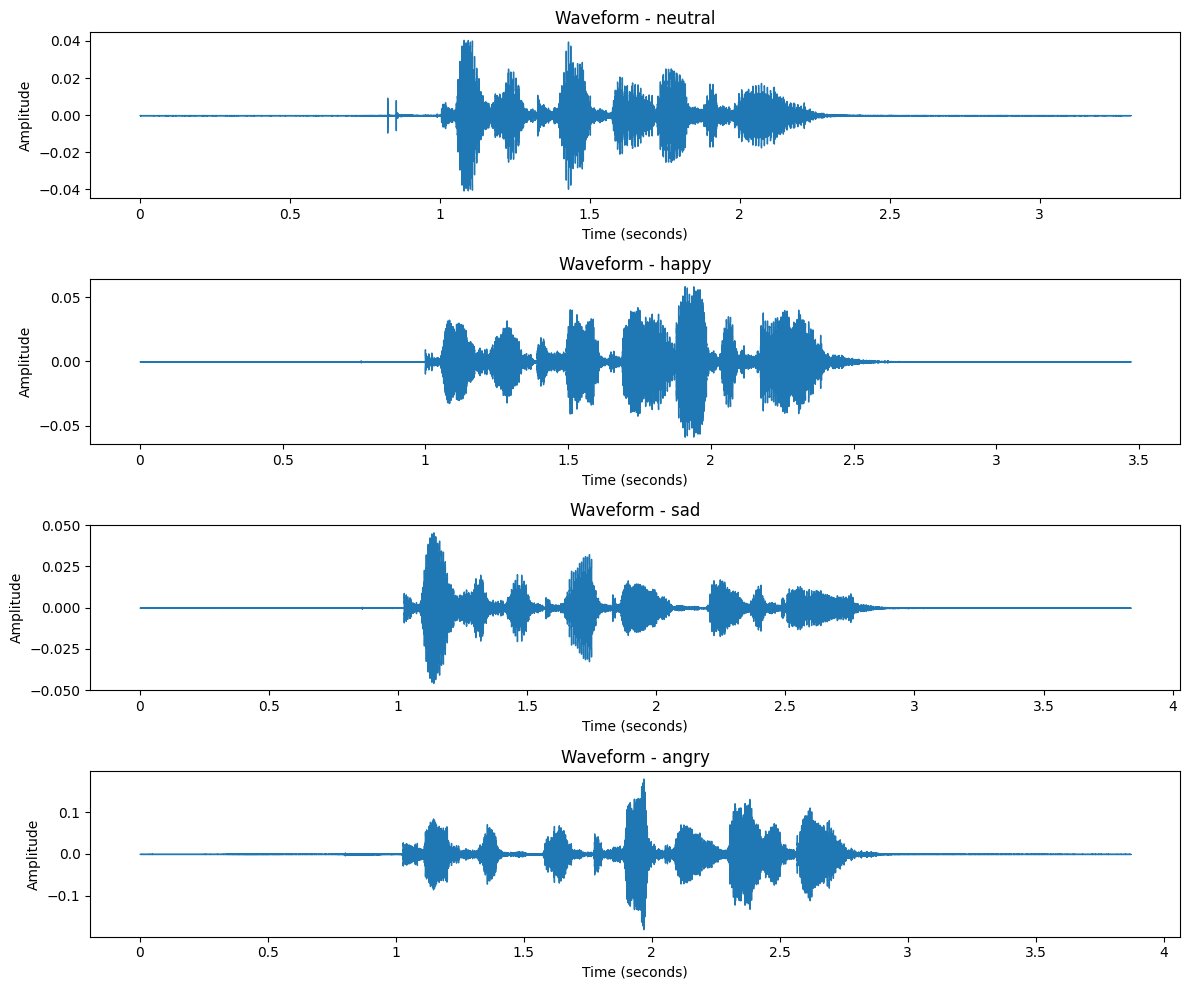

In [3]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    plt.subplot(len(emotion_order), 1, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 2. Spectrogram

A spectrogram shows how the frequency content of the audio signal changes over time.

The feature extraction algorithm used here is the **Short-Time Fourier Transform (STFT)**.

If the STFT of the audio signal is written as:

$$
X(m, k) = \sum_{n=0}^{N-1} y[n + mH] \, w[n] \, e^{-j 2\pi kn/N}
$$

then:

- $X(m, k)$ = STFT value at frame $m$ and frequency bin $k$
- $y[n]$ = audio signal
- $w[n]$ = window function
- $N$ = number of samples in one frame
- $H$ = hop length between frames
- $m$ = frame index
- $k$ = frequency bin
- $j$ = imaginary unit

The magnitude spectrogram is based on:

$$
|X(m, k)|
$$

and it is often converted to decibels as:

$$
S_{dB} = 20 \log_{10}(|X(m, k)|)
$$

In this plot:

- `y` is the audio signal
- `sr` is the sampling rate
- `D` is the STFT result
- `S_db` is the spectrogram converted to decibel scale
- `sample_file` is the selected audio file for one emotion

This figure helps us see:

- which frequencies are strong at each moment
- how the frequency content changes over time
- whether the speech has more low-frequency or high-frequency energy
- patterns that may differ across emotions

A brighter color usually means stronger energy at that time and frequency.

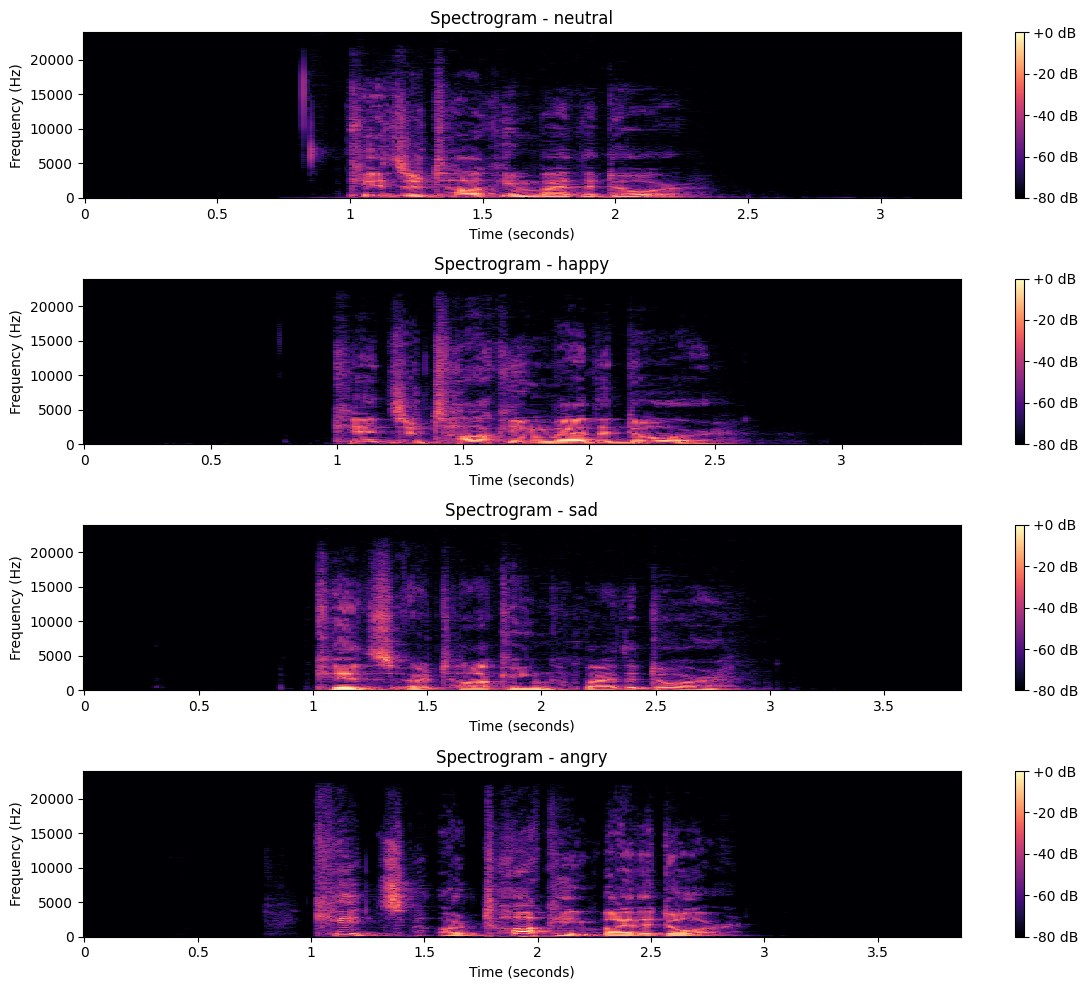

In [4]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
    plt.title(f"Spectrogram - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(img, format="%+2.0f dB")

plt.tight_layout()
plt.show()

## 2. RMS Energy

RMS energy measures the short-term strength of the signal.

The formula is:

$$
\mathrm{RMS} = \sqrt{\frac{1}{N}\sum_{n=1}^{N} y[n]^2}
$$

where:

- $y[n]$ = audio amplitude at sample $n$
- $N$ = number of samples in a frame
- RMS = root mean square energy

In this plot:

- `rms` is the RMS value for each frame
- `times` gives the corresponding time points
- `y` is the waveform
- `sr` is the sampling rate

This figure shows:

- where the speaker is louder
- where the speech is softer
- where silence or near-silence appears

Higher RMS values mean stronger energy.
This can help compare emotional intensity.

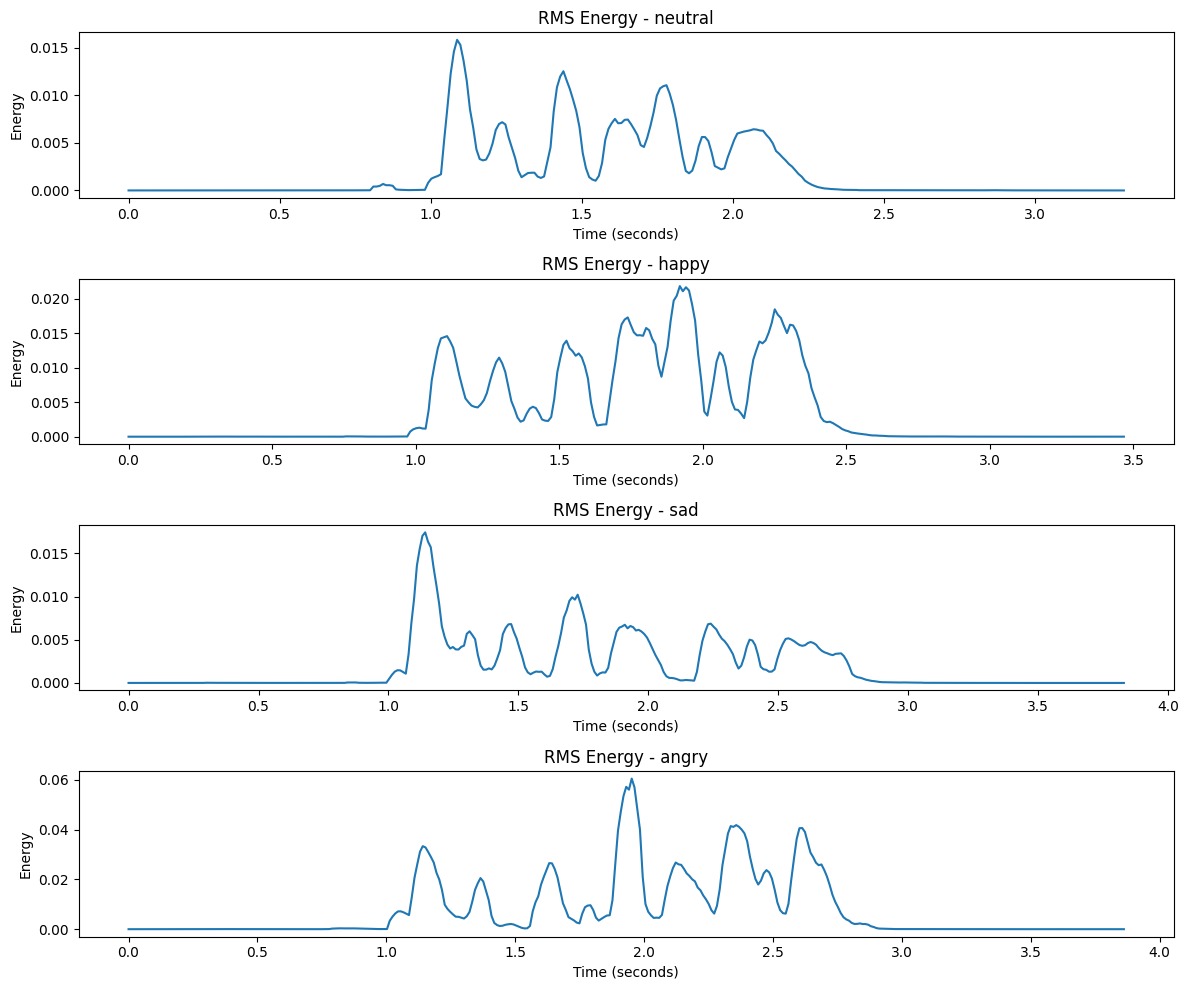

In [5]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    rms = librosa.feature.rms(y=y)[0]
    times = librosa.times_like(rms, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, rms)
    plt.title(f"RMS Energy - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Energy")

plt.tight_layout()
plt.show()

## 3. Zero Crossing Rate

Zero Crossing Rate (ZCR) counts how often the signal changes sign.

A simple expression is:

$$
\mathrm{ZCR} = \frac{1}{N-1}\sum_{n=1}^{N-1} \mathbf{1}\big(y[n]\cdot y[n-1] < 0\big)
$$

where:

- $y[n]$ = signal value at sample $n$
- $N$ = number of samples in a frame
- $\mathbf{1}(\cdot)$ = indicator function, equal to 1 if the condition is true

In this plot:

- `zcr` is the zero crossing rate for each frame
- `times` is the time axis
- `y` is the waveform

This figure helps us understand:

- how noisy or sharp the signal is
- whether the signal has more rapid oscillations

Higher ZCR often appears in noisier or higher-frequency sounds.

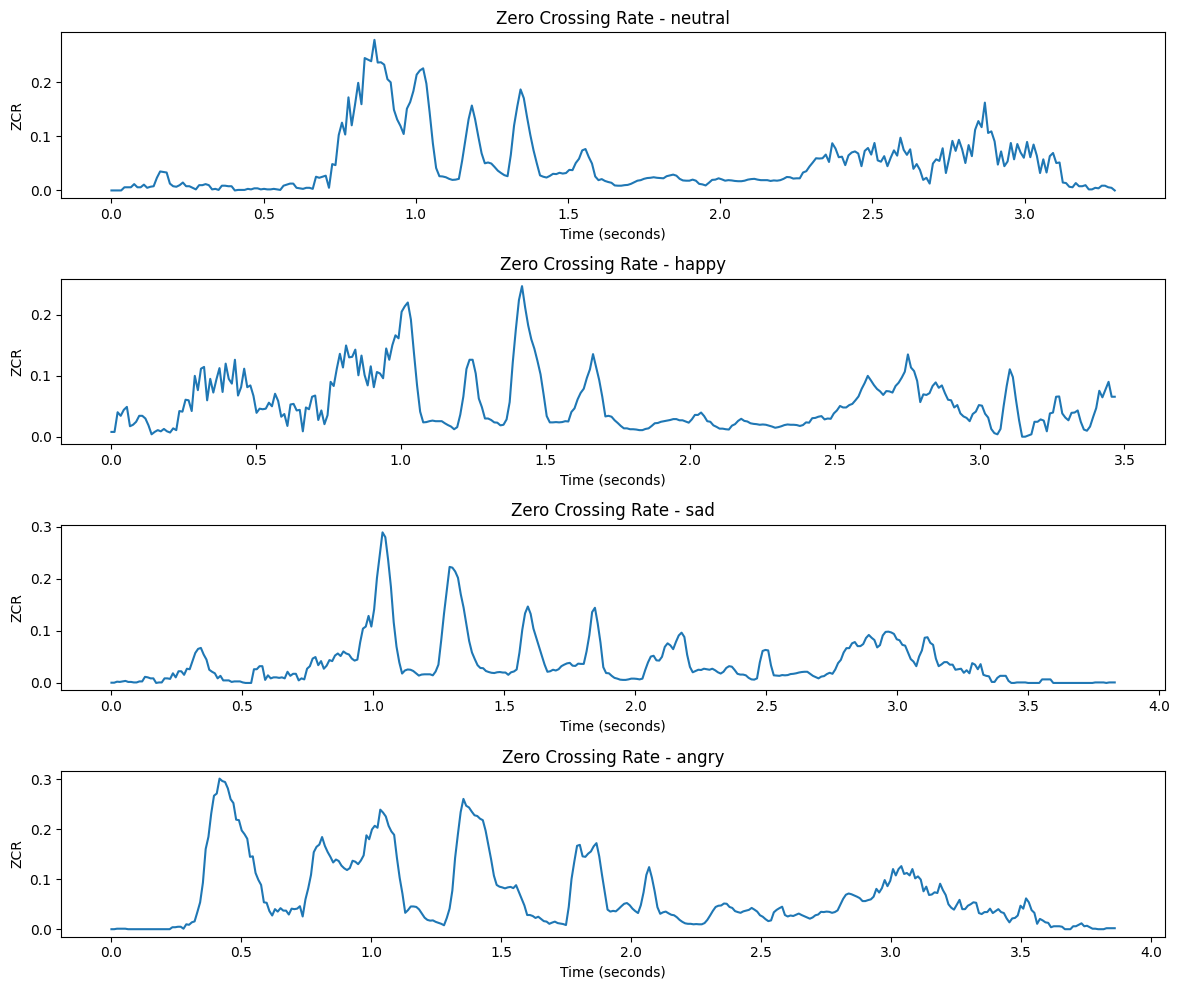

In [6]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    times = librosa.times_like(zcr, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, zcr)
    plt.title(f"Zero Crossing Rate - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("ZCR")

plt.tight_layout()
plt.show()

## 4. Pitch Contour

Pitch contour shows how the fundamental frequency changes over time.

The fundamental frequency is often written as:

$$
f_0(t)
$$

where:

- $f_0(t)$ = pitch at time $t$
- pitch is measured in Hz
- higher $f_0$ usually means a higher perceived voice pitch

In this plot:

- `f0` is the estimated pitch sequence
- `voiced_flag` shows whether a frame is voiced
- `voiced_probs` gives the probability of voicing
- `times` is the time axis

This figure helps us see:

- whether pitch rises or falls
- whether an emotion sounds flat or expressive
- changes in intonation

Happy or angry speech may show stronger pitch variation than neutral speech.

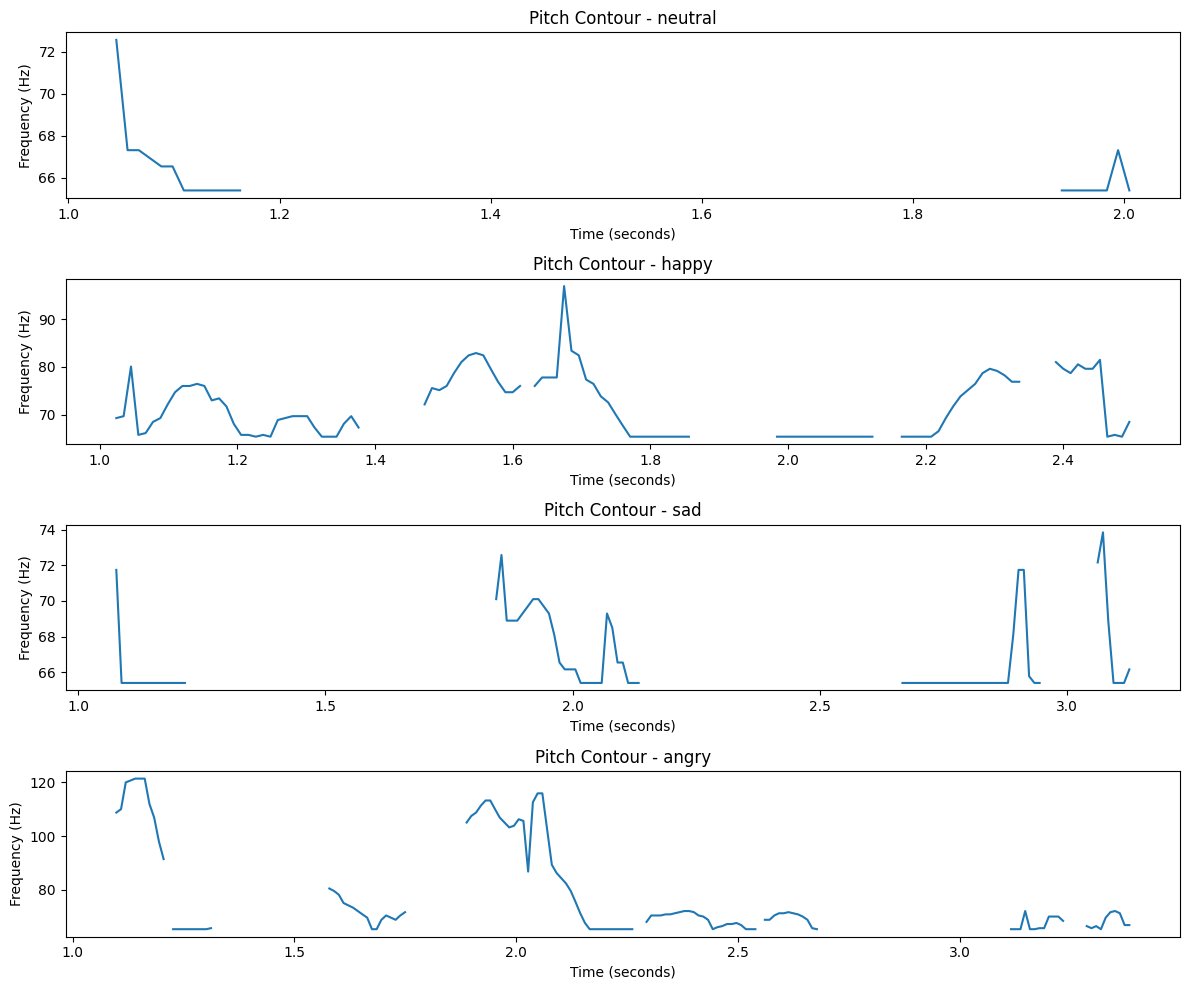

In [7]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    f0, voiced_flag, voiced_probs = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )
    times = librosa.times_like(f0, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, f0)
    plt.title(f"Pitch Contour - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

## 5. Mel Spectrogram

A Mel spectrogram shows how energy is distributed across time and frequency on the Mel scale.

It is based on the short-time Fourier transform and Mel filter banks.

A simplified idea is:

$$
S_{\mathrm{mel}}(m, t)
$$

where:

- $m$ = Mel frequency bin
- $t$ = time frame
- $S_{\mathrm{mel}}(m, t)$ = energy at Mel bin $m$ and time $t$

Then the values are often converted to decibels:

$$
S_{\mathrm{dB}} = 10 \log_{10}(S_{\mathrm{mel}})
$$

In this plot:

- `mel_spec` is the Mel spectrogram
- `mel_spec_db` is the spectrogram in decibel scale
- `n_mels=128` means 128 Mel bands are used

This figure shows:

- how frequency energy changes over time
- where strong formants or harmonics appear
- differences in low and high frequency activity

It is one of the most useful visualizations for speech analysis.

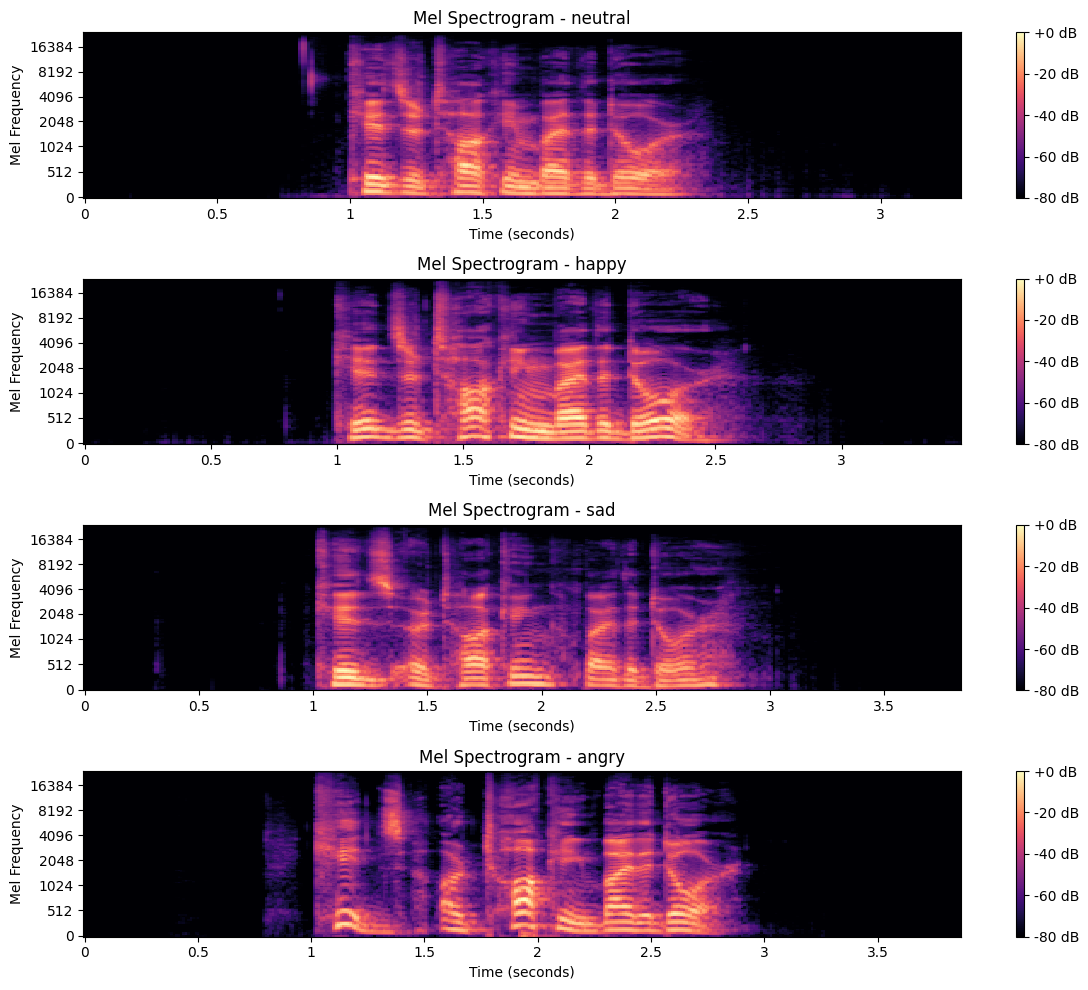

In [8]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.title(f"Mel Spectrogram - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Mel Frequency")
    plt.colorbar(img, format="%+2.0f dB")

plt.tight_layout()
plt.show()

## 6. MFCC

MFCC stands for Mel-Frequency Cepstral Coefficients.

MFCCs summarize the shape of the speech spectrum in a compact way.

A simplified process is:

1. compute the spectrum
2. apply Mel filter banks
3. take the logarithm
4. apply the discrete cosine transform (DCT)

This can be written as:

$$
\mathrm{MFCC}_k = \sum_{m=1}^{M} \log(S_{\mathrm{mel}}(m)) \cos\left[\frac{\pi k}{M}(m - 0.5)\right]
$$

where:

- $k$ = MFCC index
- $m$ = Mel filter index
- $M$ = total number of Mel filters
- $S_{\mathrm{mel}}(m)$ = Mel-scaled spectral energy

In this plot:

- `mfccs` contains the MFCC coefficients over time
- `n_mfcc=13` means 13 coefficients are extracted

This figure helps us see:

- compact spectral patterns
- differences in vocal tract characteristics
- information often used directly in machine learning models

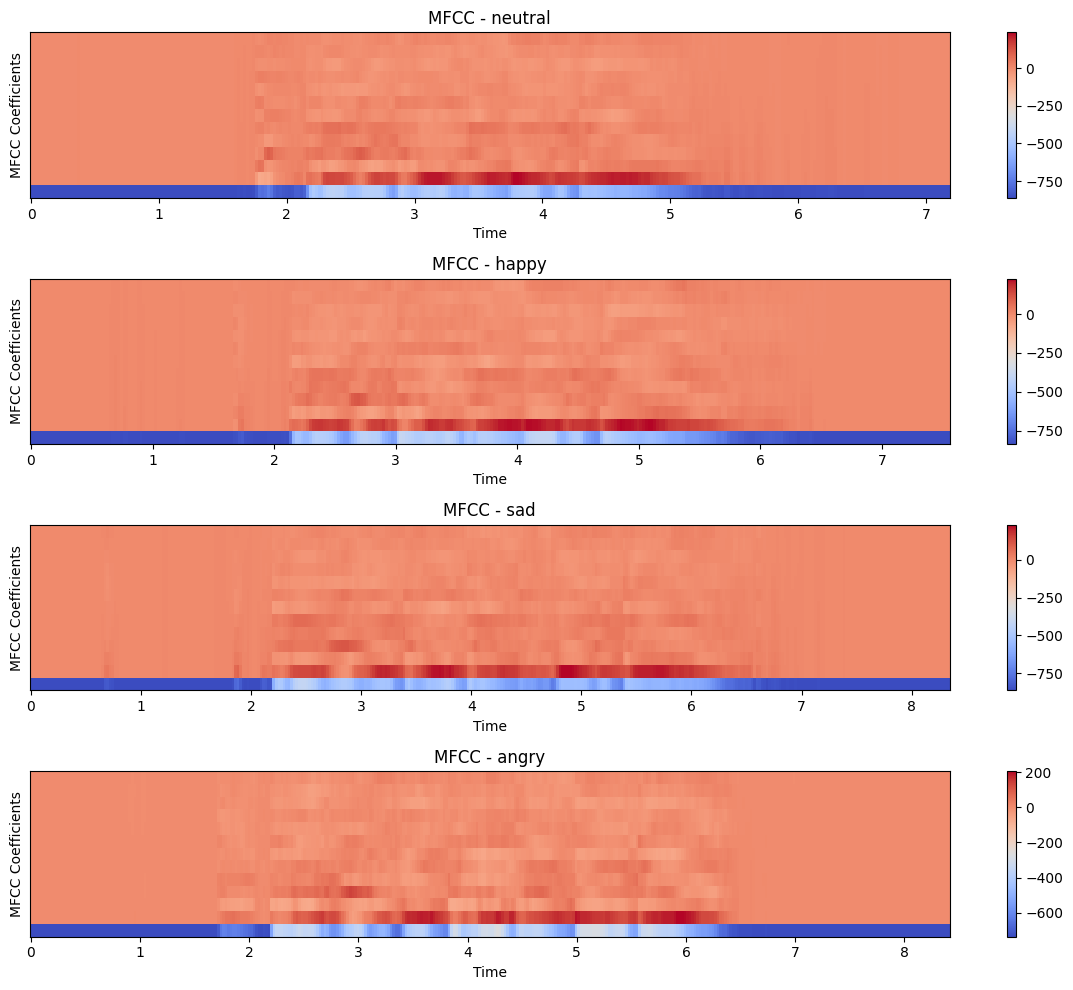

In [9]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(mfccs, x_axis="time")
    plt.title(f"MFCC - {emotion_map[emotion_code]}")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar(img)

plt.tight_layout()
plt.show()

## 7. Delta MFCC

Delta MFCC represents the rate of change of MFCC over time.

A simple approximation is:

$$
\Delta c_t = \frac{\sum_{n=1}^{N} n(c_{t+n} - c_{t-n})}{2\sum_{n=1}^{N} n^2}
$$

where:

- $c_t$ = MFCC at time $t$
- $\Delta c_t$ = temporal change of MFCC
- $N$ = window size used for the delta calculation

In this plot:

- `mfcc` is the original MFCC matrix
- `delta` is the delta MFCC matrix

This figure shows:

- how spectral properties change over time
- dynamic speech information
- transitions in articulation

This is useful because emotion is often expressed through change, not only static shape.

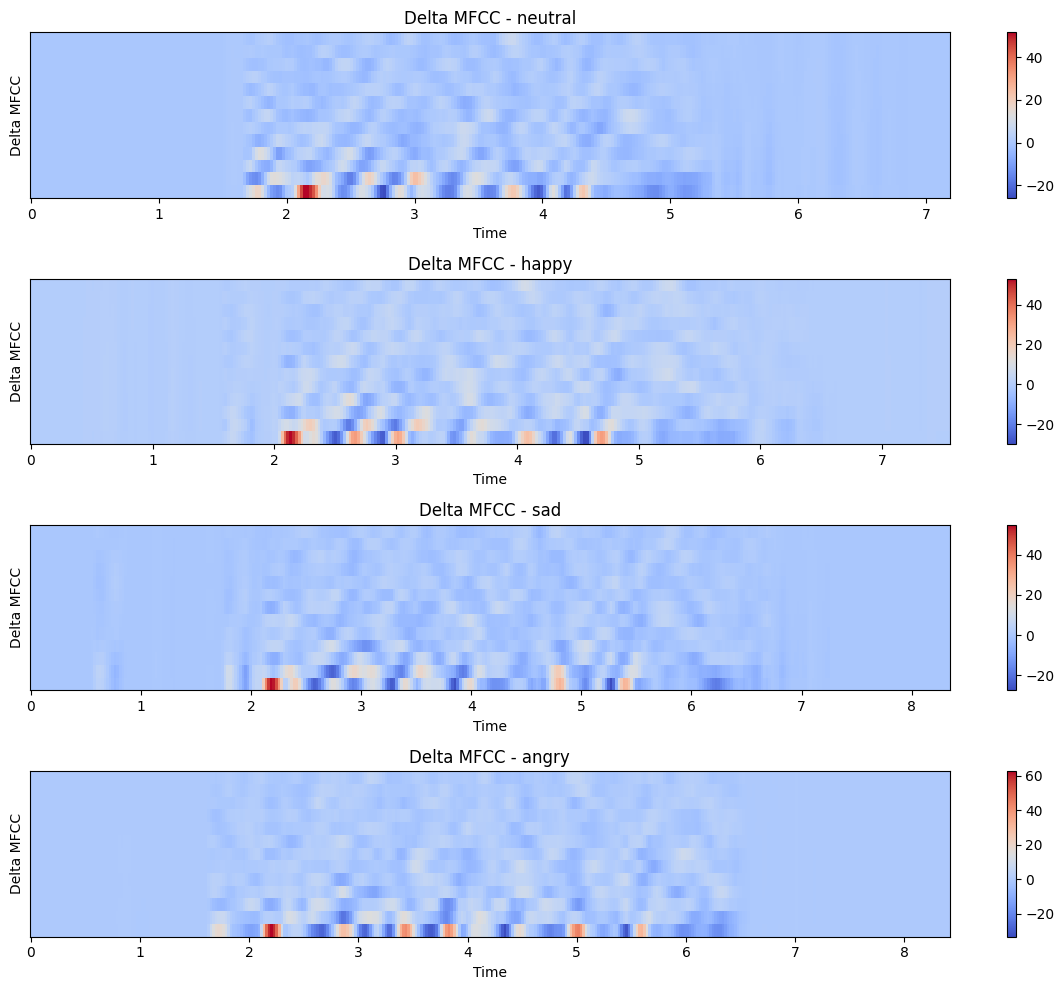

In [10]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(delta, x_axis="time")
    plt.title(f"Delta MFCC - {emotion_map[emotion_code]}")
    plt.xlabel("Time")
    plt.ylabel("Delta MFCC")
    plt.colorbar(img)

plt.tight_layout()
plt.show()

## 8. Spectral Centroid

Spectral centroid is the center of mass of the spectrum.

The formula is:

$$
\mathrm{Centroid}(t) = \frac{\sum_k f_k X(k,t)}{\sum_k X(k,t)}
$$

where:

- $f_k$ = frequency at bin $k$
- $X(k,t)$ = magnitude at frequency bin $k$ and time $t$

In this plot:

- `centroid` is the spectral centroid over time
- `times` is the time axis

This figure tells us:

- whether the sound is brighter or darker
- whether more energy is concentrated in higher frequencies

Higher centroid values usually mean a brighter sound.

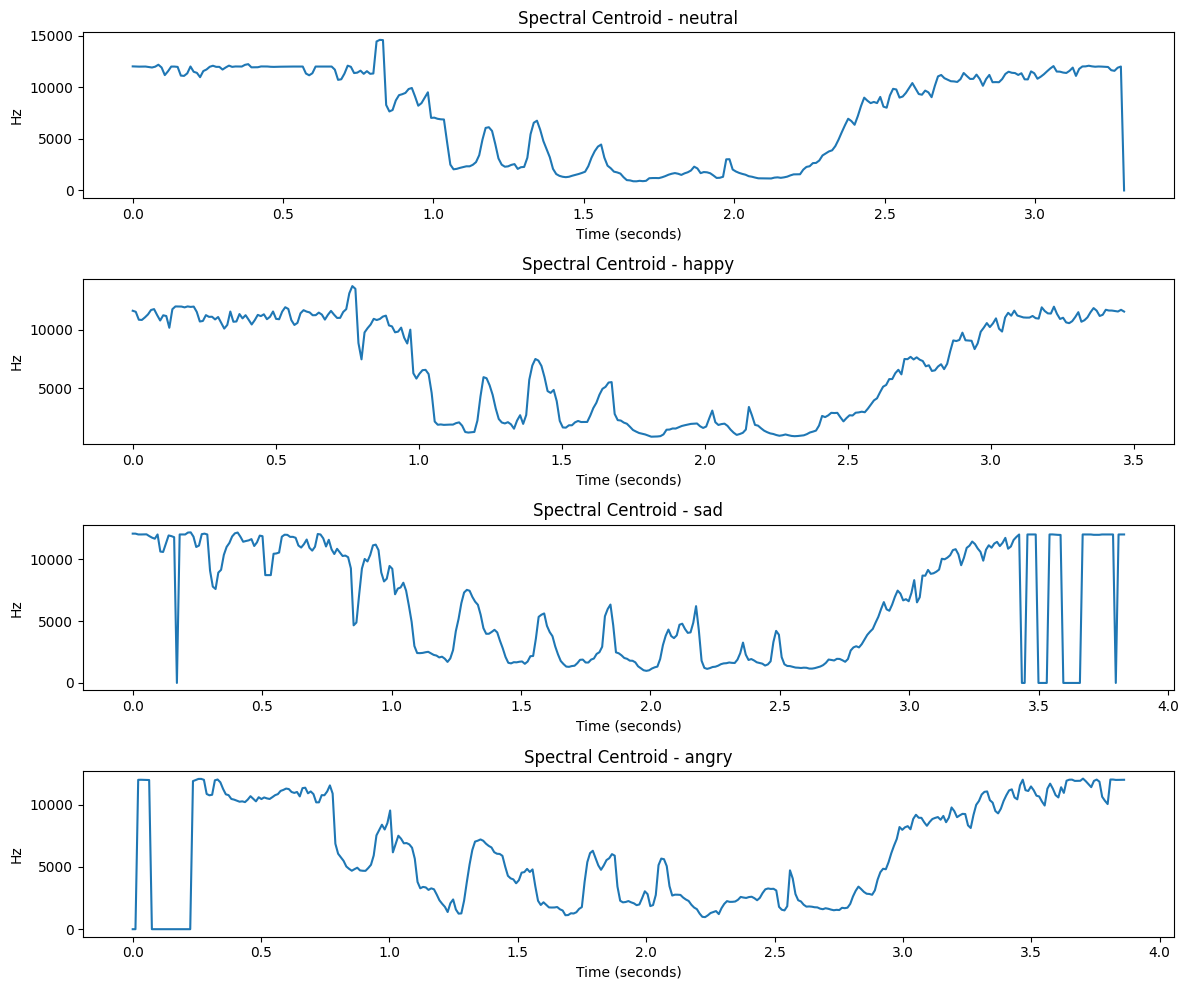

In [11]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    times = librosa.times_like(centroid, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, centroid)
    plt.title(f"Spectral Centroid - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Hz")

plt.tight_layout()
plt.show()

## 9. Spectral Bandwidth

Spectral bandwidth measures how spread out the spectrum is around the centroid.

A simplified formula is:

$$
\mathrm{Bandwidth}(t) = \left(\sum_k X(k,t)\left|f_k - \mu_t\right|^p\right)^{1/p}
$$

where:

- $f_k$ = frequency at bin $k$
- $X(k,t)$ = spectral magnitude
- $\mu_t$ = spectral centroid at time $t$
- $p$ = order of the bandwidth

In this plot:

- `bandwidth` is the spectral bandwidth over time

This figure helps us see:

- whether the sound energy is narrow or spread out
- whether the signal is concentrated or broad in frequency

Higher bandwidth often means richer or more complex frequency content.

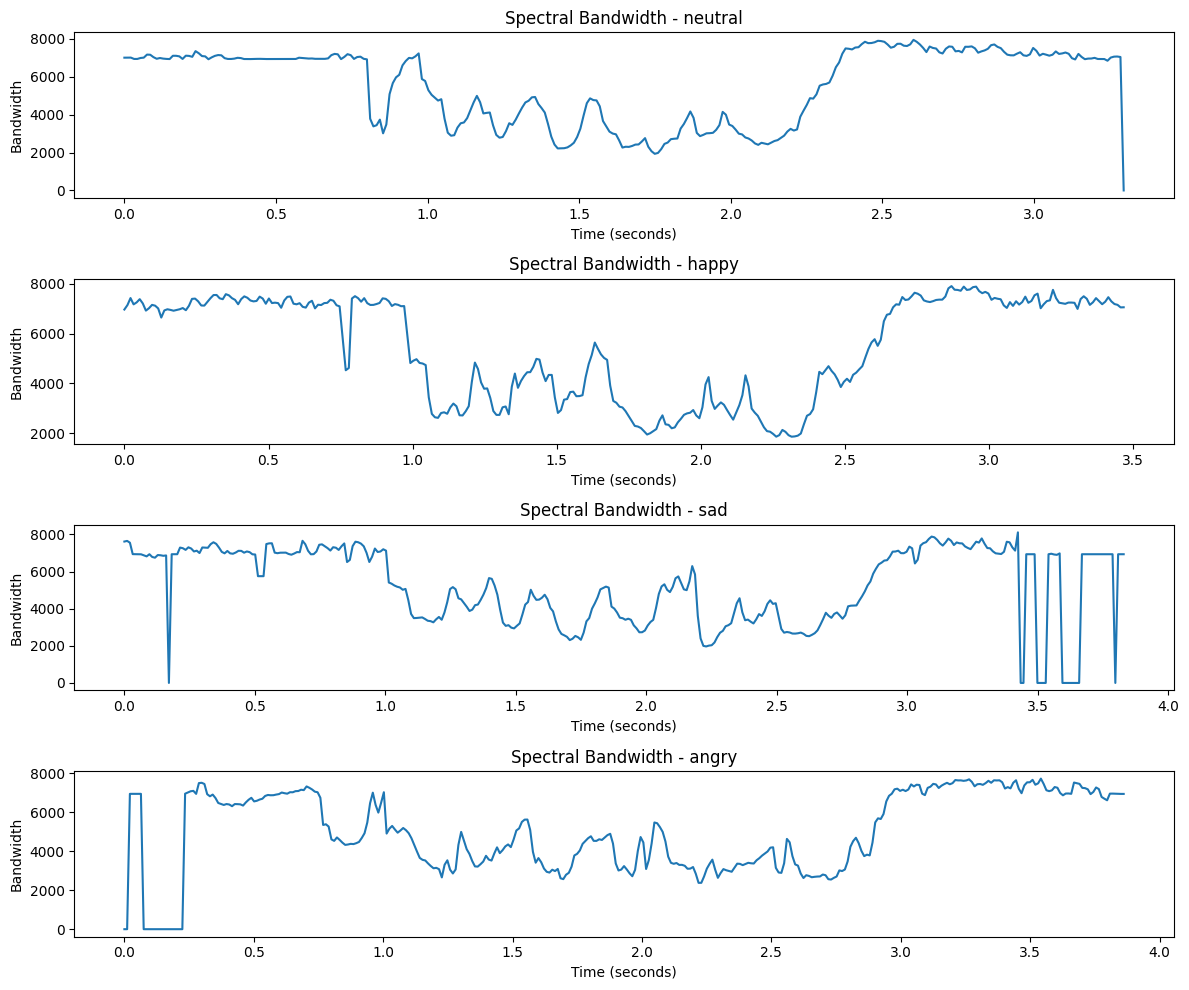

In [12]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    times = librosa.times_like(bandwidth, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, bandwidth)
    plt.title(f"Spectral Bandwidth - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Bandwidth")

plt.tight_layout()
plt.show()

## 10. Spectral Rolloff

Spectral rolloff is the frequency below which a fixed percentage of total spectral energy is contained.

It is defined as the frequency $f_r$ such that:

$$
\sum_{k=1}^{f_r} X(k,t) = \alpha \sum_{k=1}^{K} X(k,t)
$$

where:

- $X(k,t)$ = spectral magnitude
- $K$ = total number of frequency bins
- $\alpha$ = rolloff percentage, often 0.85

In this plot:

- `rolloff` is the rolloff frequency over time

This figure helps us understand:

- whether more energy is in low or high frequencies
- how sharp or bright the signal is

Higher rolloff values suggest more high-frequency content.

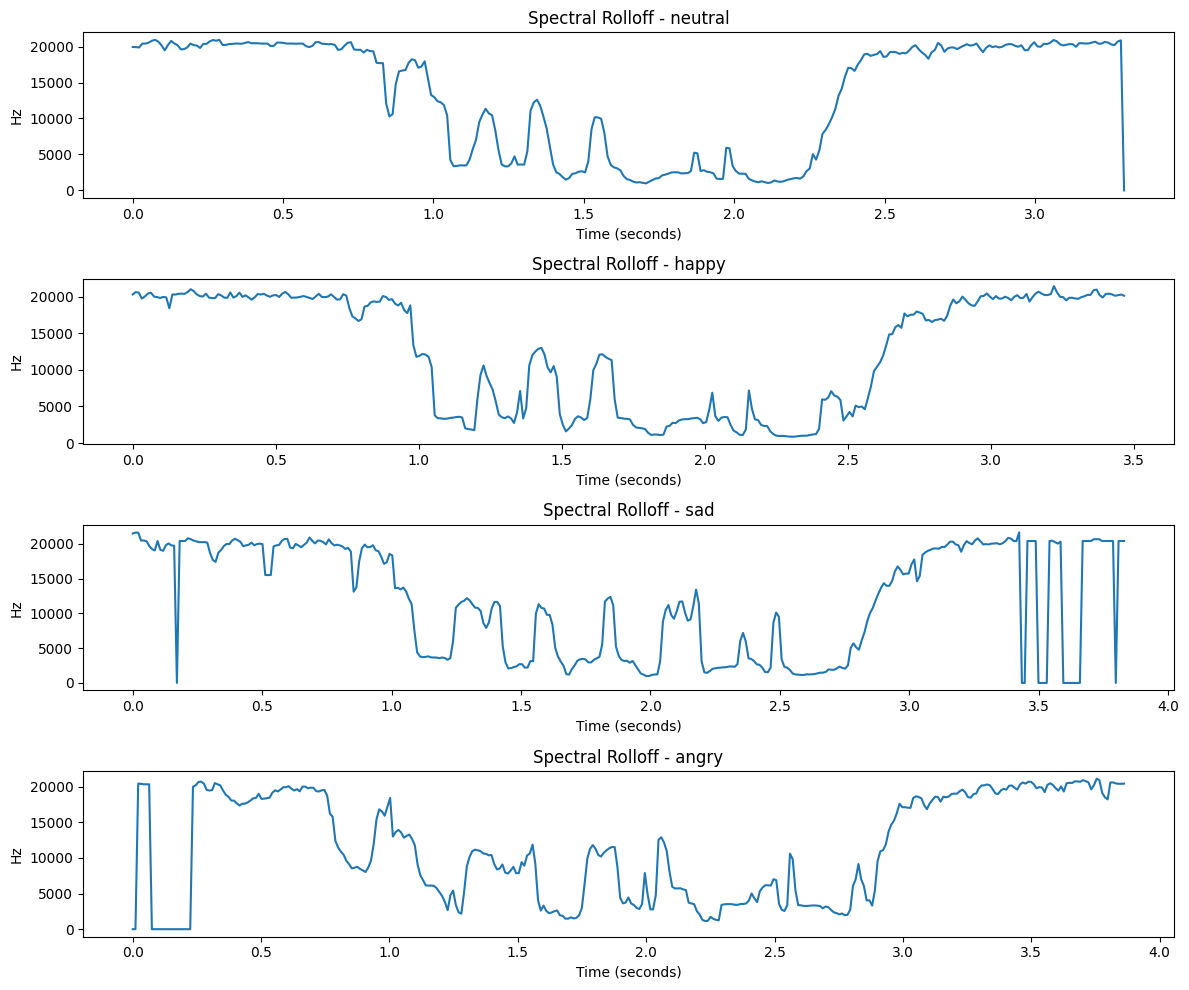

In [13]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    times = librosa.times_like(rolloff, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, rolloff)
    plt.title(f"Spectral Rolloff - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Hz")

plt.tight_layout()
plt.show()

## 11. Spectral Contrast

Spectral contrast measures the difference between spectral peaks and valleys in different frequency bands.

A simplified idea is:

$$
\mathrm{Contrast} = \text{Peak Energy} - \text{Valley Energy}
$$

In this plot:

- `contrast` is the spectral contrast matrix
- each row corresponds to one frequency band
- columns represent time frames

This figure shows:

- differences between strong and weak frequency regions
- how textured or structured the spectrum is

It can help distinguish different timbres and speech qualities.

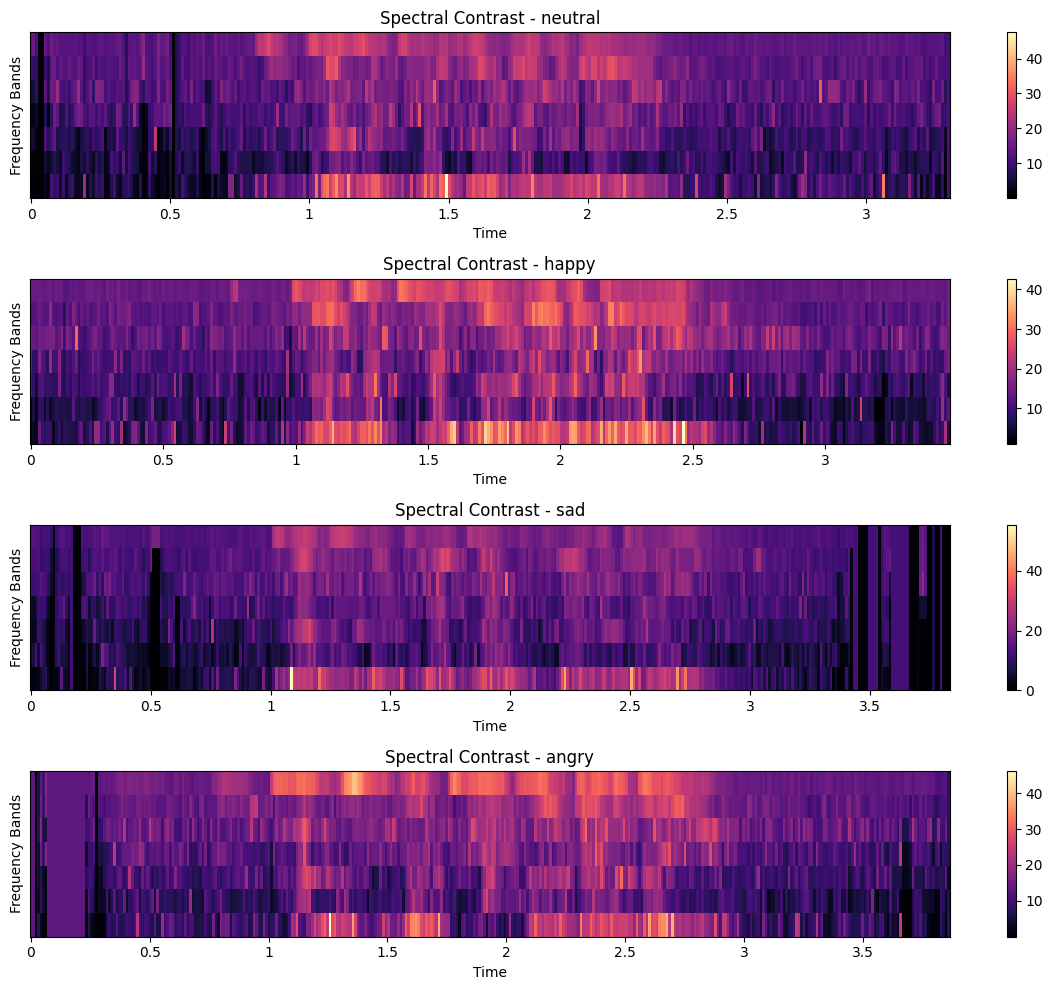

In [14]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(contrast, x_axis="time", sr=sr)
    plt.title(f"Spectral Contrast - {emotion_map[emotion_code]}")
    plt.xlabel("Time")
    plt.ylabel("Frequency Bands")
    plt.colorbar(img)

plt.tight_layout()
plt.show()

## 12. Chroma

Chroma features represent energy in the 12 pitch classes:

$$
\{C, C^\#, D, D^\#, E, F, F^\#, G, G^\#, A, A^\#, B\}
$$

In this plot:

- `chroma` is a 12-row matrix
- each row corresponds to one pitch class
- columns represent time frames

This figure shows:

- how pitch-class energy changes over time
- which pitch classes are stronger

Chroma is more common in music analysis, but it can still reveal some pitch-related structure in speech.

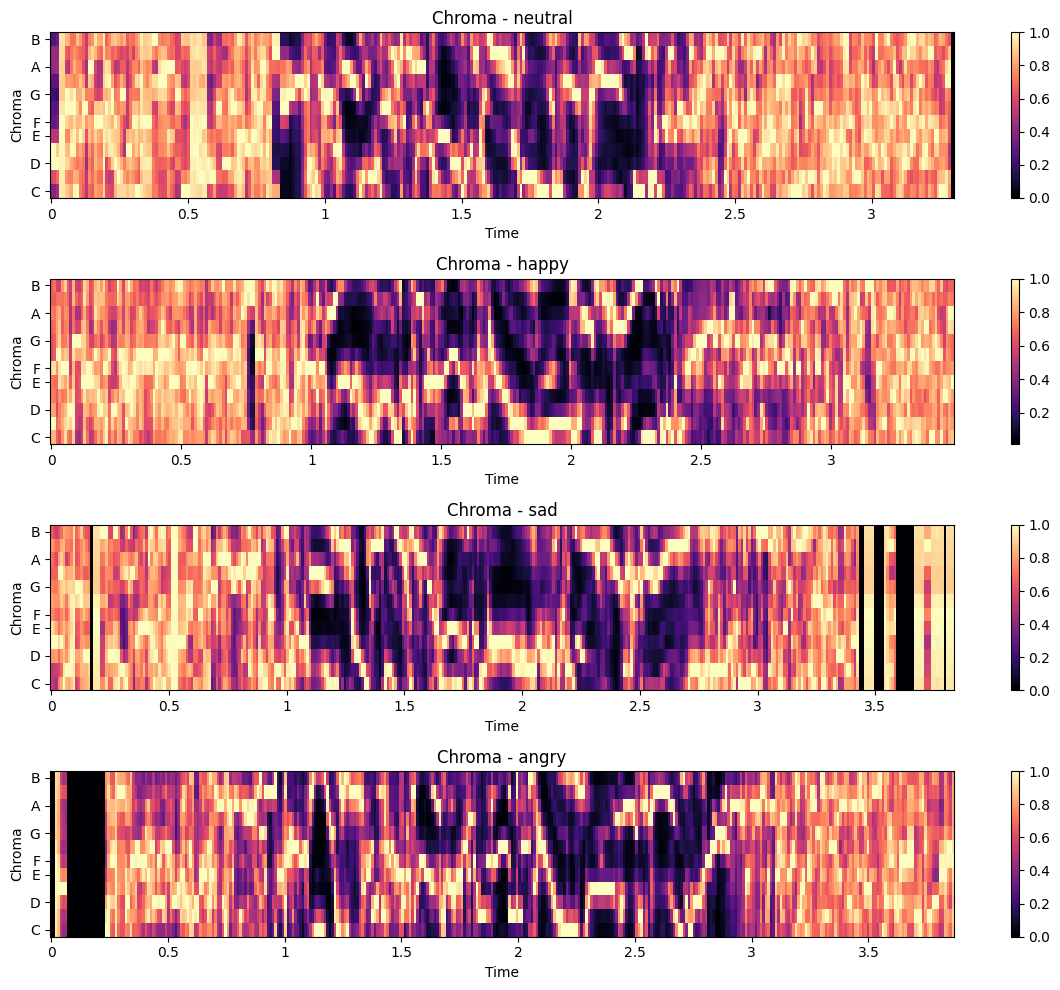

In [15]:
plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(chroma, x_axis="time", y_axis="chroma", sr=sr)
    plt.title(f"Chroma - {emotion_map[emotion_code]}")
    plt.xlabel("Time")
    plt.ylabel("Chroma")
    plt.colorbar(img)

plt.tight_layout()
plt.show()

## 13. Harmonic and Percussive Components

HPSS separates the signal into:

- harmonic component
- percussive component

This can be expressed as:

$$
y(t) = y_{\mathrm{harm}}(t) + y_{\mathrm{perc}}(t)
$$

where:

- $y(t)$ = original signal
- $y_{\mathrm{harm}}(t)$ = harmonic part
- $y_{\mathrm{perc}}(t)$ = percussive part

In this plot:

- `y_harm` is the harmonic component
- `y_perc` is the percussive component

This figure helps us understand:

- which part is smoother and tone-like
- which part is more transient and attack-like

For speech, the harmonic part is often related to voiced content,
while the percussive part may capture noisy or abrupt components.

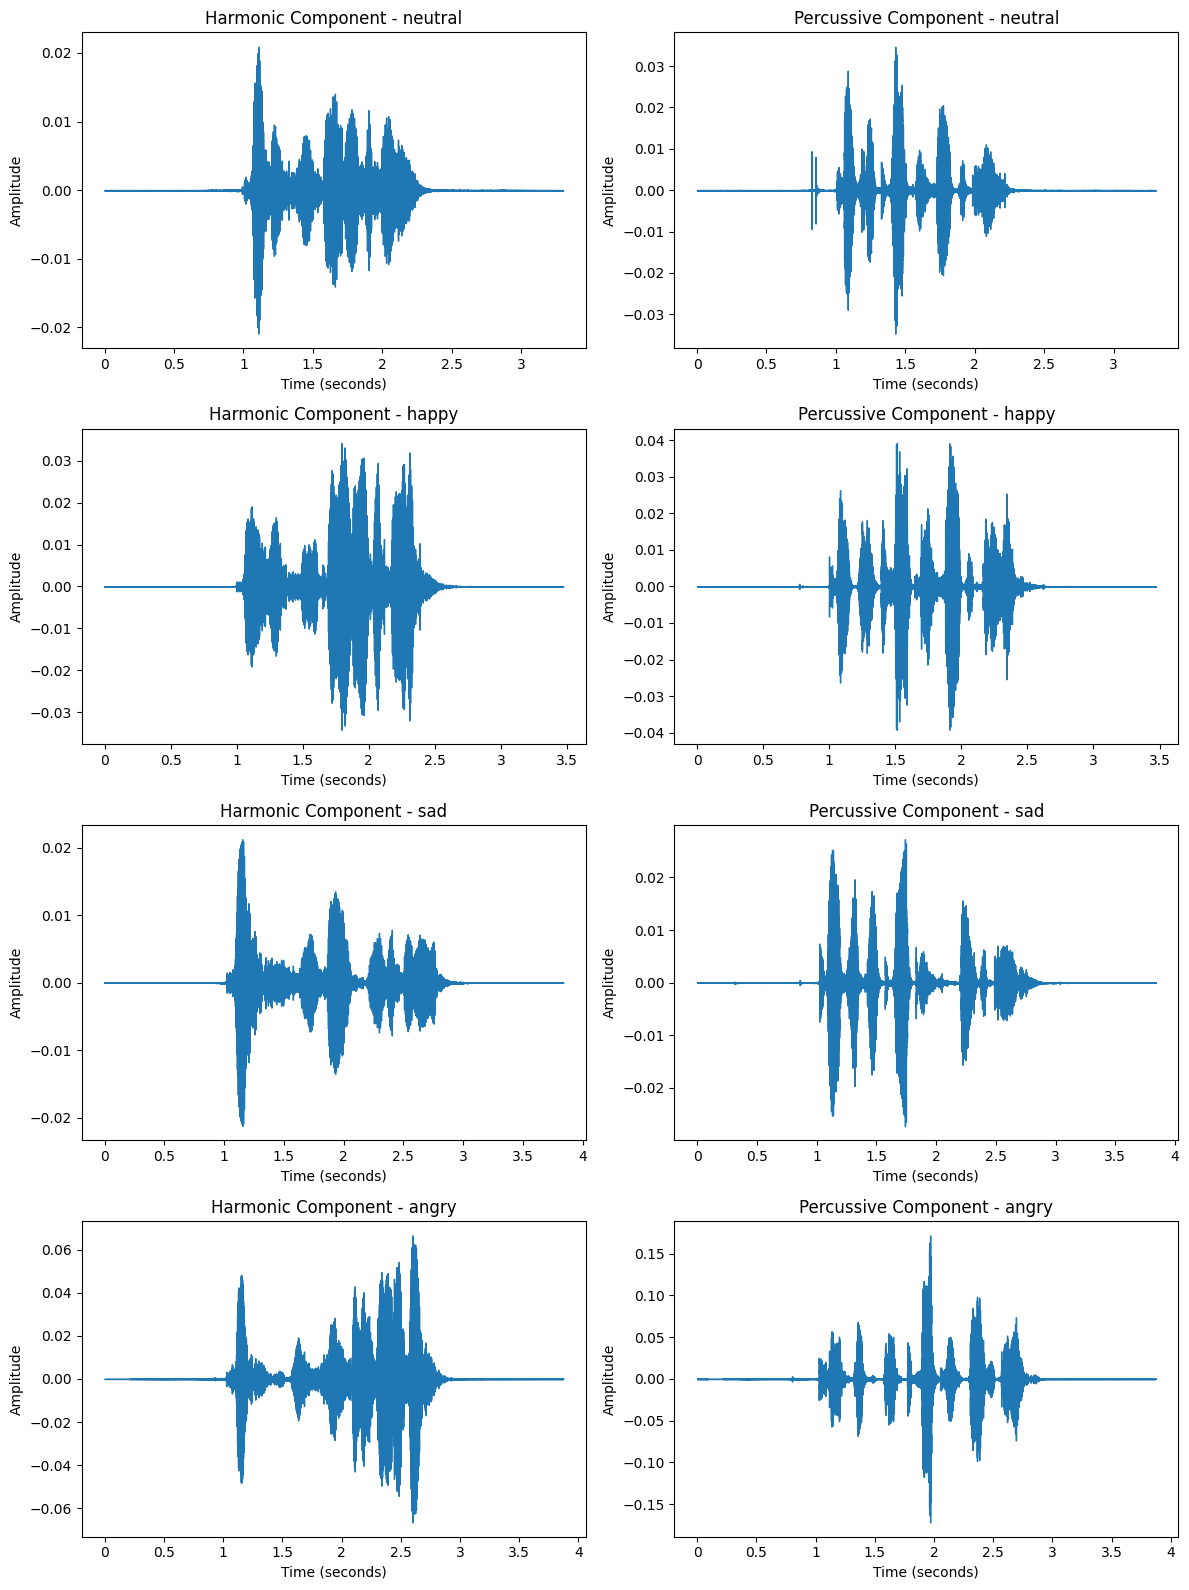

In [16]:
plt.figure(figsize=(12, 16))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    y_harm, y_perc = librosa.effects.hpss(y)

    plt.subplot(len(emotion_order), 2, 2*i - 1)
    librosa.display.waveshow(y_harm, sr=sr)
    plt.title(f"Harmonic Component - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

    plt.subplot(len(emotion_order), 2, 2*i)
    librosa.display.waveshow(y_perc, sr=sr)
    plt.title(f"Percussive Component - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

### Why I Chose Pitch Contour

I chose **Pitch Contour (F0)** as the main feature because, among the visualizations, it showed the clearest differences between emotions.

When I compared the graphs, the pitch patterns seemed easier to distinguish than many of the other features. Some emotions showed larger pitch changes, while others looked flatter and more stable. Because of this, Pitch Contour appeared to reflect emotional differences more directly.

Another reason is that pitch is closely related to **intonation** and **expressiveness** in speech. Emotional speech often changes the way a speaker raises or lowers their voice, so pitch can be a useful feature for understanding those patterns.

In addition, Pitch Contour is easy to explain intuitively. Even without advanced signal processing knowledge, it is possible to understand that this feature represents how the voice goes up and down over time.

For these reasons, I chose Pitch Contour as the most meaningful feature for my analysis.